In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import logging
import os
import warnings
import itertools
from datetime import datetime, timedelta
from functools import partial
from pathlib import Path
from optimization_engines import dwave_quantum_sharpe_minimize, genetic_algorithm_sharpe

# Load D-Wave API token from .env file
from dotenv import load_dotenv
load_dotenv()

# Set D-Wave token as environment variable
if 'DWAVE_API_TOKEN' in os.environ:
    os.environ['DWAVE_API_TOKEN'] = os.environ['DWAVE_API_TOKEN']
    print("✅ D-Wave API token loaded successfully")
else:
    print("❌ D-Wave API token not found in .env file")

SEED = 14
np.random.seed(SEED)
msg_level = logging.INFO
# Suppress all RuntimeWarnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

✅ D-Wave API token loaded successfully


## D-Wave Connection Test: CQM vs GA Optimization (10 Stocks, Single Period)

In [2]:
# Create a logger
logger = logging.getLogger("dwave_test_logger")
logger.setLevel(msg_level)  # Set the level for this logger

# Create a handler (where to send the logs)
handler = logging.StreamHandler()  # Send to the console
handler.setLevel(msg_level)

# Create a formatter (how to format the logs)
formatter = logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s")
handler.setFormatter(formatter)

# Add the handler to the logger
logger.addHandler(handler)

### Path definition

In [3]:
benchmark_path = '../../data/benchmark_gspc.pkl'
source_path = '../../data/stocks_adjclose.pkl'

### Data loading

Ticker,ds,^GSPC
0,2011-01-03,1271.869995
1,2011-01-04,1270.199951
2,2011-01-05,1276.560059
3,2011-01-06,1273.849976
4,2011-01-07,1271.500000


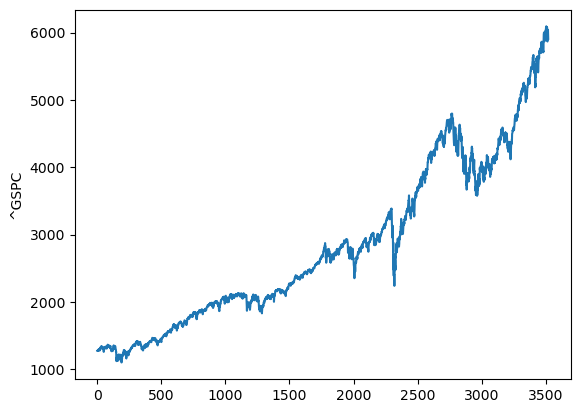

In [4]:
benchmark = pd.read_pickle(benchmark_path)
sns.lineplot(benchmark['^GSPC'])
benchmark.head()

In [5]:
source = pd.read_pickle(source_path)
print(source.shape)
# Check if any value in the DataFrame is null
has_any_nan = source.isnull().values.any()
print("Any NaN in source:", has_any_nan)
source.head()

(3522, 439)
Any NaN in source: False


Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WRB,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,6.112024,18.971697,71.104691,11.828708,76.192101,14.700940,43.098133,26.977388,47.841393,38.200001
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,6.072278,18.631702,69.911537,11.702991,78.568939,14.763333,43.300457,26.565216,47.206047,37.840000
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,6.045782,18.713308,70.882263,12.068158,79.582596,14.675976,43.184826,26.691620,47.240875,37.799999
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,5.977333,18.577297,71.084503,11.984348,80.162842,14.663502,43.462337,26.878460,45.778728,37.480000
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,5.939793,18.486635,70.963158,12.313586,83.001091,14.794533,43.699345,27.213682,45.770027,37.599998


### Select 10 stocks for connection test

In [6]:
# Simplified stock selection - rank by correlation and returns
df_corr = source.corr()
corr_sum = df_corr.map(lambda x: abs(x)).sum()
corr_rank = corr_sum.sort_values().rank(method='min').astype(int)

return_rank = source.diff().sum(axis=0).sort_values().rank(method='min', ascending=False).astype(int)
select_10 = (return_rank + corr_rank).sort_values().reset_index()['Ticker'].values[:10]
print(f"Selected 10 stocks for test: {select_10}")

Selected 10 stocks for test: ['FICO' 'LLY' 'MCK' 'CHTR' 'GWW' 'AXON' 'REGN' 'RCL' 'RL' 'TSLA']


### Portfolio Stats

In [7]:
def portfolio_stats(weights, data):
    weights = np.array(weights)
    returns = np.log(data) - np.log(data.shift(1)) # log return to minimize fp error
    port_return = np.sum(returns.mean() * weights) 
    port_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() , weights)))
    try:
        sharpe_ratio = port_return/port_vol
    except Exception as e:
        sharpe_ratio = 0
    return sharpe_ratio, port_return, port_vol

### Simple Single-Period Test Function

In [15]:
def single_period_test(optimization_function, data, test_name):
    """
    Simple single-period optimization test.
    
    Args:
        optimization_function: Function to test
        data: Stock price data
        test_name: Name for logging
    
    Returns:
        results: Dictionary with weights, stats, and timing
    """
    print(f"\n{'='*60}")
    print(f"TESTING: {test_name}")
    print(f"{'='*60}")
    
    # Use most recent 60 days of data for test
    test_data = data.iloc[-60:]
    
    # try:
    #     start_time = datetime.now()
    #     print(f"Starting optimization at {start_time}...")
        
    #     # Run optimization
    weights = optimization_function(test_data)
        
    #     end_time = datetime.now()
    #     execution_time = (end_time - start_time).total_seconds()
       
    #    # Calculate portfolio statistics
    #     sharpe, port_return, port_vol = portfolio_stats(weights, test_data)
       
    #    # Results summary
    #     results = {
    #        'test_name': test_name,
    #        'weights': weights,
    #        'sharpe_ratio': sharpe,
    #        'portfolio_return': port_return,
    #        'portfolio_volatility': port_vol,
    #        'execution_time': execution_time,
    #        'success': True,
    #        'error': None
    #     }
       
    #     print(f"✅ SUCCESS: {test_name}")
    #     print(f"   Execution time: {execution_time:.2f}s")
    #     print(f"   Sharpe ratio: {sharpe:.4f}")
    #     print(f"   Portfolio return: {port_return:.4f}")
    #     print(f"   Portfolio volatility: {port_vol:.4f}")
    #     print(f"   Weights sum: {weights.sum():.6f}")
    #     print(f"   All weights > 0: {all(w > 0 for w in weights)}")
       
    #     return results
        
    # except Exception as e:
    #     end_time = datetime.now()
    #     execution_time = (end_time - start_time).total_seconds()
        
    #     results = {
    #         'test_name': test_name,
    #         'weights': None,
    #         'sharpe_ratio': None,
    #         'portfolio_return': None,
    #         'portfolio_volatility': None,
    #         'execution_time': execution_time,
    #         'success': False,
    #         'error': str(e)
    #     }
        
    #     print(f"❌ FAILED: {test_name}")
    #     print(f"   Execution time: {execution_time:.2f}s")
    #     print(f"   Error: {e}")
        
    #     return results

### Test Parameters

In [9]:
# Parameters for single-period connection test
test_parameters = {
    # CQM parameters
    "budget": 1.0,
    "min_investment": 0.001,
    
    # GA parameters  
    "population_size": 100,
    "num_generations": 50,
    "mutation_rate": 0.1,
    "elitism": 0.1,
}

print(f"Test parameters: {test_parameters}")

Test parameters: {'budget': 1.0, 'min_investment': 0.001, 'population_size': 100, 'num_generations': 50, 'mutation_rate': 0.1, 'elitism': 0.1}


### Connection Test: 10 Stocks Dataset

Test dataset shape: (3522, 10)
Date range: 2011-01-03 00:00:00 to 2024-12-31 00:00:00


<Figure size 1200x600 with 0 Axes>

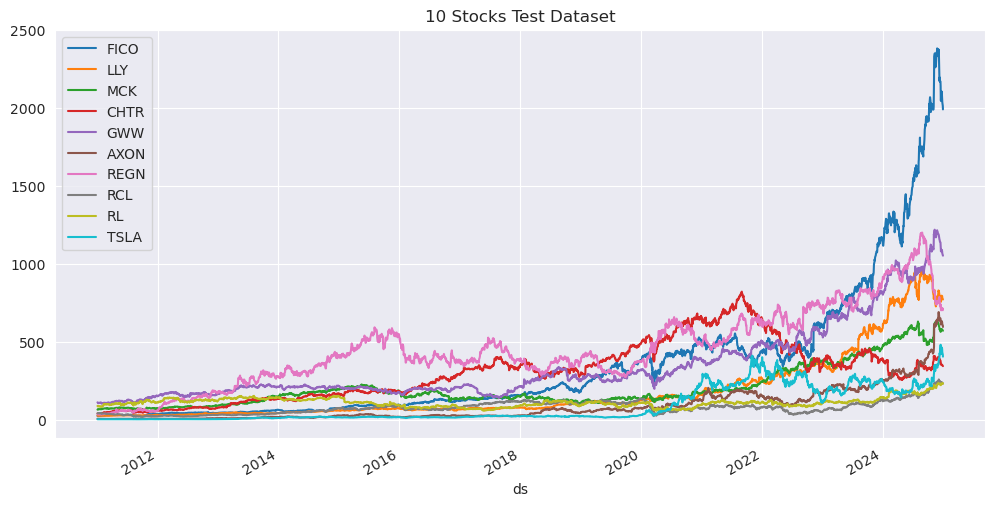

In [10]:
# Prepare 10 stocks dataset
data_10 = source[select_10]
print(f"Test dataset shape: {data_10.shape}")
print(f"Date range: {data_10.index[0]} to {data_10.index[-1]}")

# Plot the data
plt.figure(figsize=(12,6))
sns.set_style('darkgrid')
data_10.plot(figsize=(12,6))
plt.title('10 Stocks Test Dataset')
plt.legend(loc='upper left')
plt.show()

#### Test 1: D-Wave CQM Sharpe Optimization

In [16]:
# Setup CQM optimization function
cqm_optimizer = partial(
    dwave_quantum_sharpe_minimize, 
    budget=test_parameters["budget"], 
    min_investment=test_parameters["min_investment"]
)

# Run CQM test
cqm_results = single_period_test(
    cqm_optimizer, 
    data_10, 
    "D-Wave Quantum NLP Sharpe Optimization"
)


TESTING: D-Wave Quantum NLP Sharpe Optimization


D-Wave cloud connection failed: Pure D-Wave quantum solver integration required
D-Wave quantum solver failed: D-Wave quantum cloud service unavailable: Pure D-Wave quantum solver integration required


RuntimeError: Pure quantum portfolio optimization failed - no classical fallbacks allowed: D-Wave quantum cloud service unavailable: Pure D-Wave quantum solver integration required

#### Test 2: Genetic Algorithm Sharpe Optimization (Baseline)

In [12]:
# Setup GA optimization function
ga_optimizer = partial(
    genetic_algorithm_sharpe,
    population_size=test_parameters["population_size"],
    num_generations=test_parameters["num_generations"],
    mutation_rate=test_parameters["mutation_rate"],
    elitism=test_parameters["elitism"]
)

# Run GA test
ga_results = single_period_test(
    ga_optimizer,
    data_10,
    "Genetic Algorithm Sharpe Optimization"
)


TESTING: Genetic Algorithm Sharpe Optimization
Starting optimization at 2025-09-03 13:46:32.955523...
✅ SUCCESS: Genetic Algorithm Sharpe Optimization
   Execution time: 1.40s
   Sharpe ratio: 0.2870
   Portfolio return: 0.0040
   Portfolio volatility: 0.0138
   Weights sum: 1.000000
   All weights > 0: True


#### Comparison Results

In [13]:
# Compare results
print("\n" + "="*80)
print("CONNECTION TEST RESULTS SUMMARY")
print("="*80)

results = [cqm_results, ga_results]
comparison_df = pd.DataFrame([
    {
        'Method': r['test_name'],
        'Success': '✅ Yes' if r['success'] else '❌ No',
        'Time (s)': f"{r['execution_time']:.2f}" if r['execution_time'] else 'N/A',
        'Sharpe': f"{r['sharpe_ratio']:.4f}" if r['sharpe_ratio'] is not None else 'N/A',
        'Return': f"{r['portfolio_return']:.4f}" if r['portfolio_return'] is not None else 'N/A',
        'Volatility': f"{r['portfolio_volatility']:.4f}" if r['portfolio_volatility'] is not None else 'N/A',
        'Error': r['error'] if r['error'] else 'None'
    }
    for r in results
])

display(comparison_df)

# Connection status
print("\nD-WAVE CONNECTION STATUS:")
print("-" * 40)
if cqm_results['success']:
    print("🟢 D-Wave CQM connection: SUCCESSFUL")
    print(f"   ⏱️  Execution time: {cqm_results['execution_time']:.2f}s")
    print(f"   📊 Sharpe ratio achieved: {cqm_results['sharpe_ratio']:.4f}")
else:
    print("🔴 D-Wave CQM connection: FAILED")
    print(f"   ❌ Error: {cqm_results['error']}")

# Performance comparison (if both successful)
if cqm_results['success'] and ga_results['success']:
    print("\nPERFORMANCE COMPARISON:")
    print("-" * 40)
    
    # Speed comparison
    speed_ratio = cqm_results['execution_time'] / ga_results['execution_time']
    if speed_ratio < 1:
        print(f"🚀 CQM is {1/speed_ratio:.1f}x FASTER than GA")
    else:
        print(f"🐢 CQM is {speed_ratio:.1f}x SLOWER than GA")
    
    # Quality comparison
    sharpe_diff = cqm_results['sharpe_ratio'] - ga_results['sharpe_ratio']
    if sharpe_diff > 0:
        print(f"📈 CQM achieved BETTER Sharpe ratio (+{sharpe_diff:.4f})")
    elif sharpe_diff < 0:
        print(f"📉 CQM achieved LOWER Sharpe ratio ({sharpe_diff:.4f})")
    else:
        print(f"⚖️  CQM and GA achieved SAME Sharpe ratio")
        
print("\n" + "="*80)
print("TEST COMPLETED")
print("="*80)


CONNECTION TEST RESULTS SUMMARY


,Method,Success,Time (s),Sharpe,Return,Volatility,Error
0,D-Wave Quantum NLP Sharpe Optimization,❌ No,0.58,N/A,N/A,N/A,Pure quantum portfolio optimization failed - n...
1,Genetic Algorithm Sharpe Optimization,✅ Yes,1.40,0.2870,0.0040,0.0138,None



D-WAVE CONNECTION STATUS:
----------------------------------------
🔴 D-Wave CQM connection: FAILED
   ❌ Error: Pure quantum portfolio optimization failed - no classical fallbacks allowed: D-Wave quantum cloud service unavailable: Pure D-Wave quantum solver integration required

TEST COMPLETED


#### Weights Comparison (if both successful)

In [14]:
# Compare portfolio weights if both methods successful
if cqm_results['success'] and ga_results['success']:
    # Create weights comparison DataFrame
    weights_df = pd.DataFrame({
        'Stock': select_10,
        'CQM_Weights': cqm_results['weights'],
        'GA_Weights': ga_results['weights'],
    })
    weights_df['Difference'] = weights_df['CQM_Weights'] - weights_df['GA_Weights']
    weights_df = weights_df.round(4)
    
    print("PORTFOLIO WEIGHTS COMPARISON:")
    display(weights_df)
    
    # Visualize weights comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Bar plot comparison
    x = np.arange(len(select_10))
    width = 0.35
    
    ax1.bar(x - width/2, cqm_results['weights'], width, label='D-Wave CQM', alpha=0.8)
    ax1.bar(x + width/2, ga_results['weights'], width, label='Genetic Algorithm', alpha=0.8)
    ax1.set_xlabel('Stocks')
    ax1.set_ylabel('Portfolio Weights')
    ax1.set_title('Portfolio Weights Comparison')
    ax1.set_xticks(x)
    ax1.set_xticklabels(select_10, rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Scatter plot correlation
    ax2.scatter(cqm_results['weights'], ga_results['weights'], alpha=0.7)
    ax2.plot([0, max(max(cqm_results['weights']), max(ga_results['weights']))], 
             [0, max(max(cqm_results['weights']), max(ga_results['weights']))], 
             'r--', alpha=0.5, label='Perfect Correlation')
    ax2.set_xlabel('CQM Weights')
    ax2.set_ylabel('GA Weights')
    ax2.set_title('Weights Correlation')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Add stock labels to scatter plot
    for i, stock in enumerate(select_10):
        ax2.annotate(stock, (cqm_results['weights'][i], ga_results['weights'][i]), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate correlation between weight allocations
    weights_correlation = np.corrcoef(cqm_results['weights'], ga_results['weights'])[0, 1]
    print(f"\nWeights correlation between CQM and GA: {weights_correlation:.4f}")
    
else:
    print("Cannot compare weights - one or both optimization methods failed.")

Cannot compare weights - one or both optimization methods failed.
